# Plot FWC, OHC, MLD, SIC when ice bridge is present over Mackenzie Plume

In [2]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import datetime
import warnings
import matplotlib as mpl
warnings.filterwarnings("ignore", module='distributed')

In [3]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:41411")
client

<Client: 'tcp://127.0.0.1:41411' processes=8 threads=32, memory=123.95 GiB>

In [4]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [5]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [6]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [7]:
# open SALT zarr store - [psu]
SALT_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
SI_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options)

# open HEFF zarr store
heff_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIheff_AVG_DAILY.ZARR/', s3_options)

In [8]:
# remove 2021 since we only have January and a few days in Feb that year
salt_day = SALT_zarr_day.SALT.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
theta_day = THETA_zarr_day.THETA.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
ice_day = SI_zarr_day.SIarea.sel(time=slice("2014","2020")).where(HH_grid.mask_basin.isel(k=0)==1)*100 # convert to percentage

In [9]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

### Manual dates

In [17]:
ice_dates_plume = np.array(['2014-10-29T12',
                            '2015-10-11T12',
                            '2016-10-22T12',
                            '2017-10-26T12',
                            '2018-10-13T12',
                            '2019-10-26T12',
                            '2020-10-25T12'], dtype='datetime64[ns]')

In [11]:
ice_dates_plume

array(['2014-10-30T12:00:00.000000000', '2015-10-11T12:00:00.000000000',
       '2016-10-22T12:00:00.000000000', '2017-10-26T12:00:00.000000000',
       '2018-10-13T12:00:00.000000000', '2019-10-26T12:00:00.000000000',
       '2020-10-25T12:00:00.000000000'], dtype='datetime64[ns]')

### open datasets

In [12]:
# open OHC zarr stores
fwc_ds = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/FWC/FWC_Beaufort.ZARR')
fwc_da = fwc_ds.fwc

ohc_mld_ds = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/OHC/OHC_MLD_Beaufort.ZARR')
ohc_mld_da = ohc_mld_ds.ohc

mld_ds = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/MLD/MLD_Beaufort_updated.ZARR')
mld_da = mld_ds.mld

In [18]:
# select just beaufort region and ice date for each year
fwc_icedays = fwc_da.sel(time=ice_dates_plume)
ohc_icedays = ohc_mld_da.sel(time=ice_dates_plume)
mld_icedays = mld_da.sel(time=ice_dates_plume)
sic_icedays = ice_day.sel(time=ice_dates_plume).isel(i=slice(450,750),j=slice(110,390))

In [14]:
# select only beaufort land and bathy
land_beaufort = HH_grid_land.isel(i=slice(450,750),j=slice(110,390))
bathy_beaufort = HH_grid.isel(i=slice(450,750),j=slice(110,390)).Depth

In [19]:
# rotate arrays
land_flip = xr.DataArray(np.rot90(land_beaufort,3), dims=['i','j'])
bathy_flip = xr.DataArray(np.rot90(bathy_beaufort,3), dims=['i','j']).load()

rotated_data = xr.DataArray(np.rot90(fwc_icedays,3, axes=(1, 2)))
fwc_flip = xr.DataArray(rotated_data, dims=['time', 'i', 'j']).load()

rotated_data = xr.DataArray(np.rot90(ohc_icedays,3, axes=(1, 2)))
ohc_flip = xr.DataArray(rotated_data, dims=['time', 'i', 'j']).load()

rotated_data = xr.DataArray(np.rot90(mld_icedays,3, axes=(1, 2)))
mld_flip = (xr.DataArray(rotated_data, dims=['time', 'i', 'j'])*-1).load()

rotated_data = xr.DataArray(np.rot90(sic_icedays,3, axes=(1, 2)))
sic_flip = xr.DataArray(rotated_data, dims=['time', 'i', 'j']).load()

### Plot map of MLD, SSS, SST, and SIC

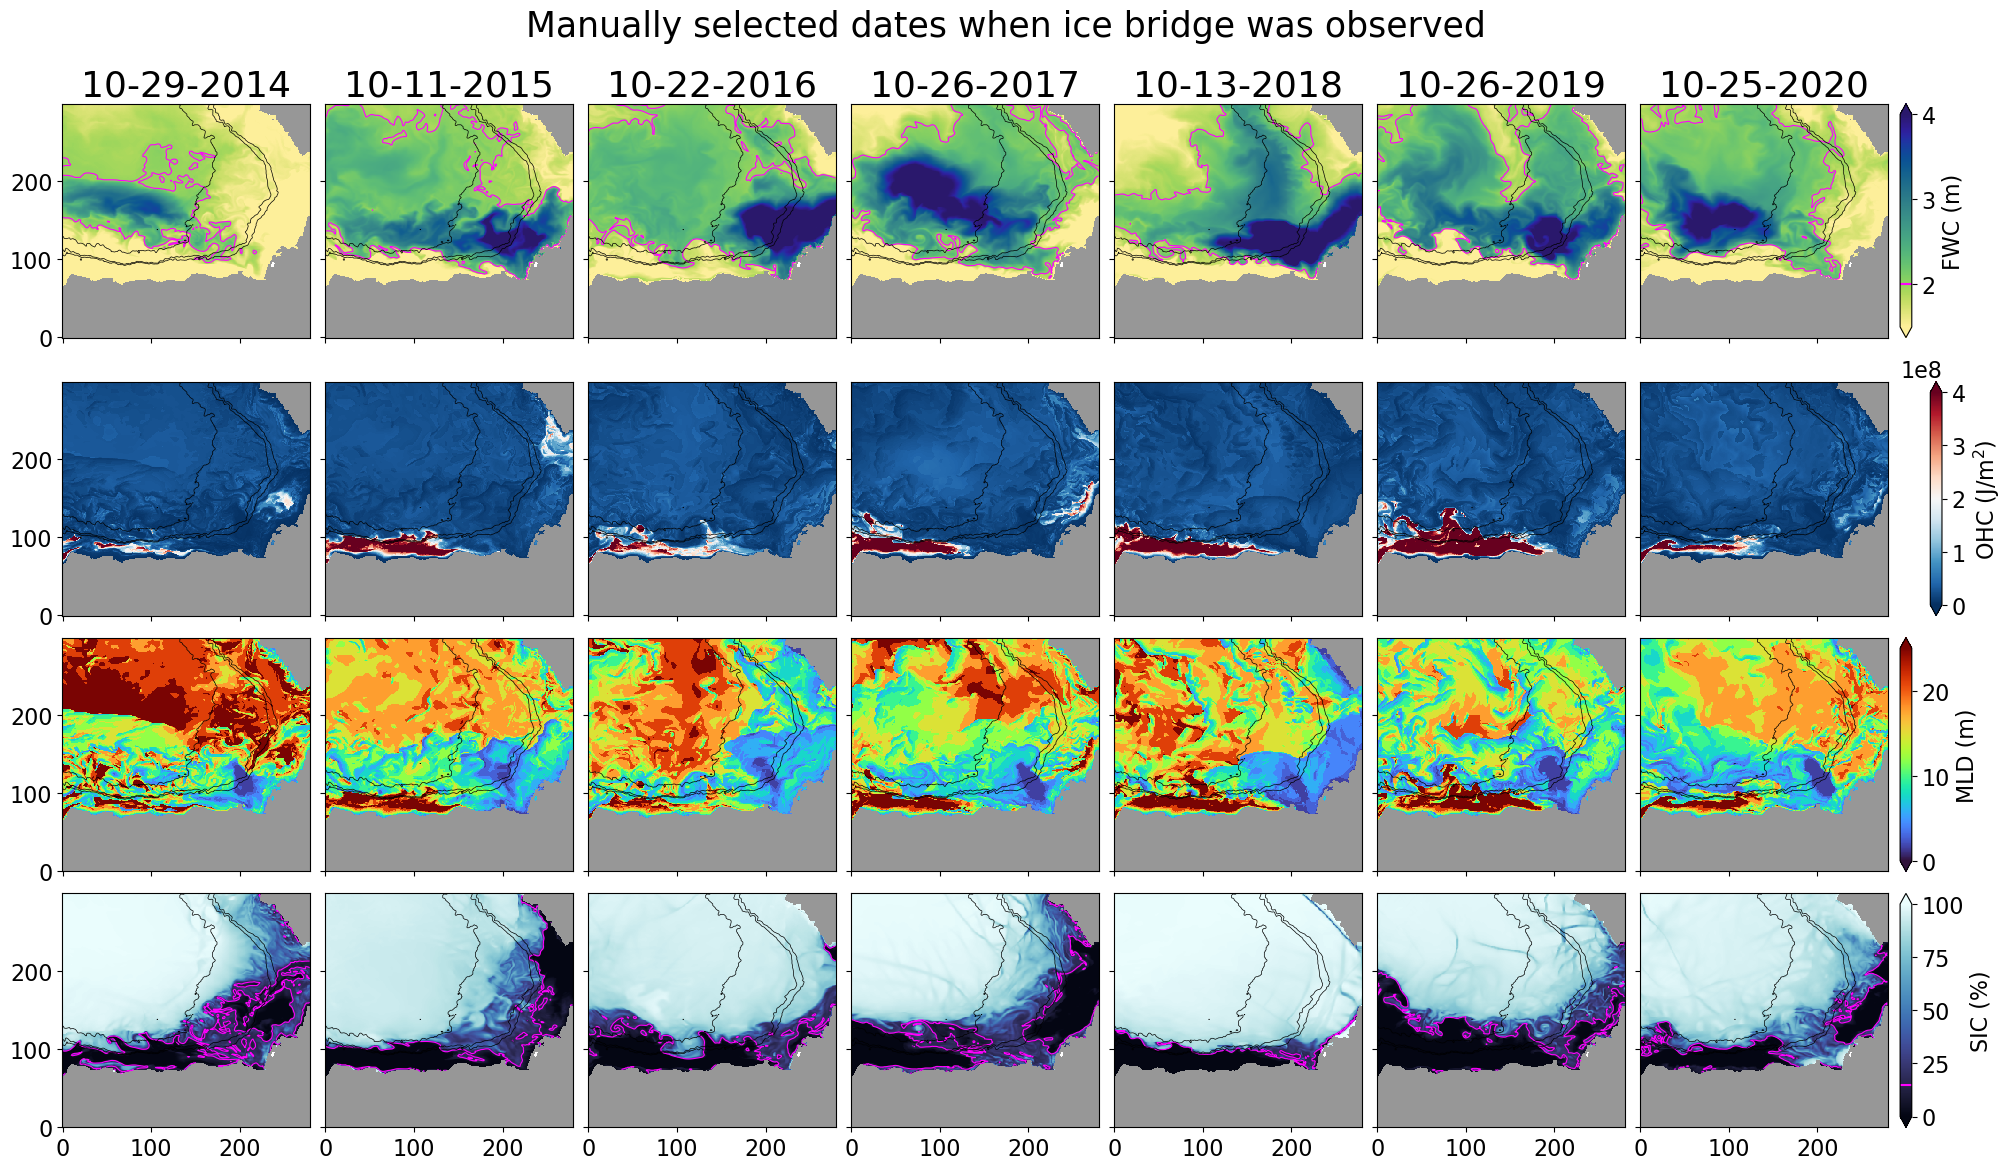

In [20]:
# Set up the figure and subplots (4 rows, 7 columns) with Cartopy
plt.rcParams['font.size'] = 16
fig, axes = plt.subplots(4, 7, figsize=(20, 11), sharex=True, sharey=True, layout='constrained')

# Define the colormap and range for each dataset
vmin_fwc = 1.5
vmax_fwc = 4
vmin_ohc = 0
vmax_ohc = 4e8
vmin_mld = 0
vmax_mld = 25
vmin_sic = 0
vmax_sic = 100

# Loop through each year and plot all variables
for year in range(0, 7):
    
    # FWC (Row 1)
    ax = axes[0, year]
    fwc_flip.isel(time=year).plot(ax=ax, cmap=cmocean.cm.haline_r, vmin=vmin_fwc, vmax=vmax_fwc, add_colorbar=False)
    fwc_flip.isel(time=year).plot.contour(ax=ax, levels=[2], linewidths=0.8, colors='magenta', add_colorbar=False)
    land_flip.plot(ax=ax, cmap='Greys_r', add_colorbar=False)
    bathy_flip.plot.contour(ax=ax, colors='k', linewidths=0.5, levels=[500,1000,3000])
    # ax.set_title(str(fwc_icedays.isel(time=year).time.values)[0:10],fontsize=26)
    ax.set_title(datetime.datetime.strptime(str(fwc_icedays.isel(time=year).time.values)[0:10], '%Y-%m-%d').strftime('%m-%d-%Y'), fontsize=26)
    
    # SST (Row 2)
    ax = axes[1, year]
    ohc_flip.isel(time=year).plot(ax=ax, cmap='RdBu_r', vmin=vmin_ohc, vmax=vmax_ohc, add_colorbar=False)
    land_flip.plot(ax=ax, cmap='Greys_r', add_colorbar=False)
    bathy_flip.plot.contour(ax=ax, colors='k', linewidths=0.5, levels=[500,1000,3000])
    ax.set_title("")

    # MLD (Row 3)
    ax = axes[2, year]
    mld_flip.isel(time=year).plot(ax=ax, cmap='turbo', vmin=vmin_mld, vmax=vmax_mld, add_colorbar=False)
    land_flip.plot(ax=ax, cmap='Greys_r', add_colorbar=False)
    bathy_flip.plot.contour(ax=ax, colors='k', linewidths=0.5, levels=[500,1000,3000])
    ax.set_title("")
    
    # SIC (Row 4)
    ax = axes[3, year]
    sic_flip.isel(time=year).plot(ax=ax, cmap=cmocean.cm.ice, vmin=vmin_sic, vmax=vmax_sic, add_colorbar=False)
    sic_flip.isel(time=year).plot.contour(ax=ax, levels=[15], linewidths=0.8, colors='magenta', add_colorbar=False)
    land_flip.plot(ax=ax, cmap='Greys_r', add_colorbar=False)
    bathy_flip.plot.contour(ax=ax, colors='k', linewidths=0.5, levels=[500,1000,3000])
    ax.set_title("")
    
# Add colorbars to the last column
colorbars = [
    (cmocean.cm.haline_r, vmin_fwc, vmax_fwc, 'FWC (m)'),
    ('RdBu_r', vmin_ohc, vmax_ohc, 'OHC (J/m$^2$)'),
    ('turbo', vmin_mld, vmax_mld, 'MLD (m)'),
    (cmocean.cm.ice, vmin_sic, vmax_sic, 'SIC (%)')
]

# for i, (cmap, vmin, vmax, label) in enumerate(colorbars):
#     cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=axes[i, -1], location='right',extend='both')
#     cbar.ax.set_ylabel(label)

# Define contour levels to mark on colorbars
contour_lines = [2, None, None, 15]  # Only FWC and SIC have magenta contours

for i, (cmap, vmin, vmax, label) in enumerate(colorbars):
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=axes[i, -1], location='right', extend='both')
    cbar.ax.set_ylabel(label)

    # Add magenta contour line to colorbar if defined
    if contour_lines[i] is not None:
        cbar_val = contour_lines[i]
        # Normalize to the colorbar scale
        cbar.ax.axhline([cbar_val], color='magenta', linewidth=1.5)

for ax in axes.flatten():
    ax.set_xlabel("")
    ax.set_ylabel("")

# Set the main title
plt.suptitle('Manually selected dates when ice bridge was observed', fontsize=25, y=1.05);

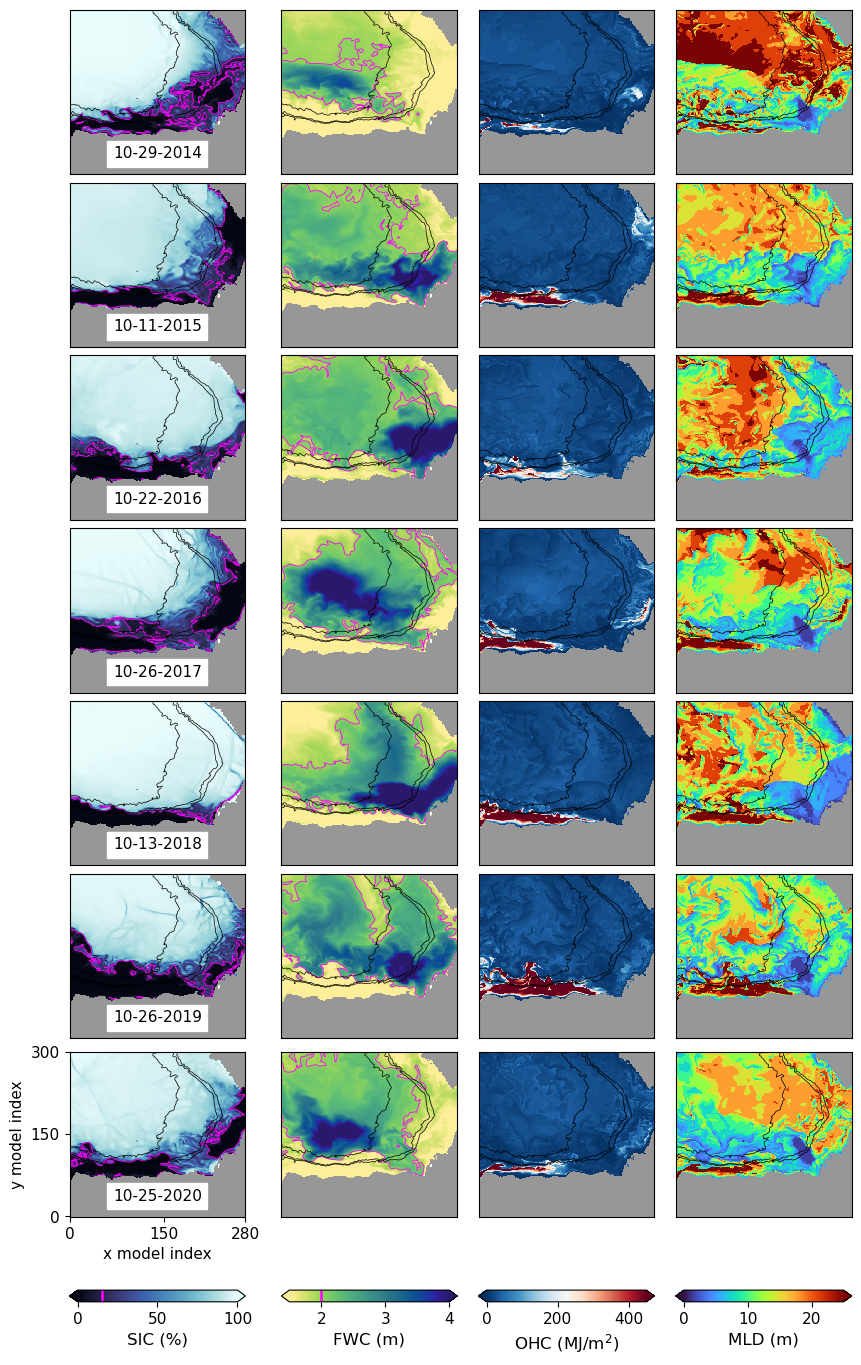

In [21]:
# Set up the figure and subplots (7 rows for years, 4 columns for variables)
plt.rcParams['font.size'] = 11
fig, axes = plt.subplots(7, 4, figsize=(8.5, 13.5), layout='constrained',gridspec_kw={'wspace': 0.1})

# Define the colormap and range for each dataset
vmin_fwc, vmax_fwc = 1.5, 4
vmin_ohc, vmax_ohc = 0, 450
vmin_mld, vmax_mld = 0, 25
vmin_sic, vmax_sic = 0, 100

# Loop through each year and plot all variables (columns: FWC, OHC, MLD, SIC)
for year in range(7):
    # Format the date string
    date_str = datetime.datetime.strptime(str(fwc_icedays.isel(time=year).time.values)[0:10], '%Y-%m-%d').strftime('%m-%d-%Y')

    # Column 0: SIC
    ax = axes[year, 0]
    sic_flip.isel(time=year).plot(ax=ax, cmap=cmocean.cm.ice, vmin=vmin_sic, vmax=vmax_sic, add_colorbar=False)
    sic_flip.isel(time=year).plot.contour(ax=ax, levels=[15], linewidths=0.6, colors='magenta', add_colorbar=False)
    land_flip.plot(ax=ax, cmap='Greys_r', add_colorbar=False)
    bathy_flip.plot.contour(ax=ax, colors='k', linewidths=0.5, levels=[500, 1000, 3000])
    ax.set_ylabel(date_str, fontsize=14)

    # Add date as a text box with white background at bottom center
    ax.text(0.5, 0.17, date_str, transform=ax.transAxes,
            ha='center', va='top', fontsize=11, color='black',
            bbox=dict(facecolor='white', edgecolor='white'))

    # Column 1: FWC
    ax = axes[year, 1]
    fwc_flip.isel(time=year).plot(ax=ax, cmap=cmocean.cm.haline_r, vmin=vmin_fwc, vmax=vmax_fwc, add_colorbar=False)
    fwc_flip.isel(time=year).plot.contour(ax=ax, levels=[2], linewidths=0.6, colors='magenta', add_colorbar=False)
    land_flip.plot(ax=ax, cmap='Greys_r', add_colorbar=False)
    bathy_flip.plot.contour(ax=ax, colors='k', linewidths=0.5, levels=[500, 1000, 3000])

    # Column 2: OHC
    ax = axes[year, 2]
    (ohc_flip.isel(time=year)/1e6).plot(ax=ax, cmap='RdBu_r', vmin=vmin_ohc, vmax=vmax_ohc, add_colorbar=False)
    land_flip.plot(ax=ax, cmap='Greys_r', add_colorbar=False)
    bathy_flip.plot.contour(ax=ax, colors='k', linewidths=0.5, levels=[500, 1000, 3000])

    # Column 3: MLD
    ax = axes[year, 3]
    mld_flip.isel(time=year).plot(ax=ax, cmap='turbo', vmin=vmin_mld, vmax=vmax_mld, add_colorbar=False)
    land_flip.plot(ax=ax, cmap='Greys_r', add_colorbar=False)
    bathy_flip.plot.contour(ax=ax, colors='k', linewidths=0.5, levels=[500, 1000, 3000])

# Remove axis titles for all subplots
for ax in axes.flatten():
    ax.set_title("")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticks([])
    ax.set_xticks([])

axes[year, 0].set_yticks([0,150,300])
axes[year, 0].set_xticks([0,150,280])
axes[year, 0].set_ylabel("y model index",size=11)
axes[year, 0].set_xlabel("x model index",size=11)

# Leave space for colorbars
# fig.subplots_adjust(bottom=0.12)

# Add horizontal colorbars below each column
colorbars = [(cmocean.cm.ice, vmin_sic, vmax_sic, 'SIC (%)', 0, 15),
             (cmocean.cm.haline_r, vmin_fwc, vmax_fwc, 'FWC (m)', 1, 2),
             ('RdBu_r', vmin_ohc, vmax_ohc, 'OHC (MJ/m$^2$)', 2, None),
             ('turbo', vmin_mld, vmax_mld, 'MLD (m)', 3, None)]

for cmap, vmin, vmax, label, col, contour_val in colorbars:
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=axes[:, col],  # all rows in this column
        orientation='horizontal',
        pad=0.02,
        aspect=15,
        extend='both'
    )
    cbar.set_label(label, fontsize=12)
    if contour_val is not None:
        # rel_pos = contour_val - vmin) / (vmax - vmin)
        cbar.ax.axvline(contour_val, color='magenta', linewidth=1.8)

# Set main title
# plt.suptitle('Manually selected dates when ice bridge was observed', fontsize=14, y=1.03)

plt.show()

fig.savefig('/home/jpluser/git_repos/SASSIE_ECCO_salinity_stratification/figures/ice_bridge_maps.png', \
            dpi=300, bbox_inches='tight')